C:\Users\Tobia\Anaconda3\lib\site-packages\ipykernel_launcher.py:19: DataConversionWarning: Data with input dtype int64 were all converted to float64 by the scale function.


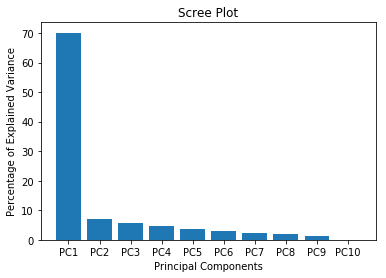

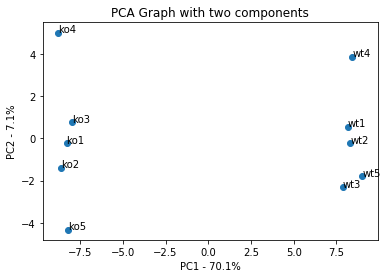

gene2    -0.119169
gene36   -0.118666
gene55    0.118339
gene68   -0.118315
gene32   -0.118214
gene17   -0.117910
gene22   -0.117893
gene51    0.117887
gene74   -0.117624
gene79    0.117613
dtype: float64


In [58]:
import pandas as pd
import numpy as np
import random as rd
from sklearn.decomposition import PCA
from sklearn import preprocessing
import matplotlib.pyplot as plt

genes = ['gene' + str(i) for i in range(1,101)]

wt = ['wt' + str(i) for i in range(1,6)]
ko = ['ko' + str(i) for i in range(1,6)]

data = pd.DataFrame(index = [*wt, *ko], columns = genes)

for gene in data.columns:
    data.loc['wt1':'wt5', gene] = np.random.poisson(lam = rd.randrange(10,100), size = 5)
    data.loc['ko1':'ko5', gene] = np.random.poisson(lam = rd.randrange(10,100), size = 5)

scaled_data = preprocessing.scale(data)

pca = PCA()
pca.fit(scaled_data)
pca_data = pca.transform(scaled_data)

per_var = np.round(pca.explained_variance_ratio_ * 100, decimals = 1)
labels = ['PC' + str(x) for x in range(1, len(per_var) + 1)]

plt.bar(x = range(1, len(per_var) + 1), height = per_var, tick_label = labels)
plt.ylabel('Percentage of Explained Variance')
plt.xlabel('Principal Components')
plt.title('Scree Plot')
plt.show()

pca_df = pd.DataFrame(pca_data, index = [*wt, *ko], columns = labels)

plt.scatter(pca_df.PC1, pca_df.PC2)
plt.title('PCA Graph with two components')
plt.xlabel('PC1 - {0}%'.format(per_var[0]))
plt.ylabel('PC2 - {0}%'.format(per_var[1]))

for sample in pca_df.index:
    plt.annotate(sample, (pca_df.PC1.loc[sample], pca_df.PC2.loc[sample]))
    
plt.show()

loading_scores = pd.Series(pca.components_[0], index = genes)
sorted_loading_scores = loading_scores.abs().sort_values(ascending = False)

top_10_genes = sorted_loading_scores[0:10].index.values

print(loading_scores[top_10_genes])


